In [1]:
import os
from datetime import datetime
import math
import matplotlib.pyplot as plt
from matplotlib.transforms import ScaledTranslation
import numpy as np

# Imports from PyTorch.
import torch
import torchvision
from torch import nn
from torchvision import datasets, transforms
from torch import nn, Tensor, device, no_grad, manual_seed
from torch import max as torch_max
from torch.utils.data import DataLoader
from torchvision.datasets.utils import download_url
import torch.optim.lr_scheduler as lr_scheduler
import torch.nn.functional as F
from copy import deepcopy
#import

import sys
# get the path of the current file
file = os.path.abspath('')
path = os.path.join(file, '../')
sys.path.append(path)
print(path)


# Imports from aihwkit.
from aihwkit.nn import AnalogConv2d, AnalogLinear, AnalogSequential
from aihwkit.optim import AnalogSGD
from aihwkit.simulator.configs.configs import (
    InferenceRPUConfig,
    TorchInferenceRPUConfig,
    # remember, the InferenceRPUConfig configuration parameter is used only for inference:
    # this means that the hardware non-idealities are considered only in the forward pass,
    # while the backward and update passes are ideal.
)
from aihwkit.simulator.configs import MappingParameter
from aihwkit.simulator.configs import (
    SingleRPUConfig,
    FloatingPointRPUConfig,
    ConstantStepDevice,
    FloatingPointDevice,
)


from aihwkit.simulator.parameters import (
    WeightClipParameter,
    WeightQuantizerParameter,
)
from aihwkit.simulator.parameters.enums import WeightQuantizerType

from aihwkit.nn.conversion import convert_to_analog, convert_to_digital
from aihwkit.simulator.presets import StandardHWATrainingPreset
from aihwkit.simulator.parameters.enums import WeightClipType
src = os.getcwd()
src = os.path.abspath(os.path.join(src, '../src'))
sys.path.append(src)

from src.noise import NullNoiseModel, ExperimentalNoiseModel, CompensatedExperimentalNoiseModel, SingleConductanceNoiseModel, CompensatedSingleConductanceNoiseModel


from aihwkit.simulator.rpu_base import cuda

cur_dir = os.getcwd()
print("Current directory: ", cur_dir)
src_path = os.path.join(cur_dir, "..")
sys.path.append(src_path)
import src.plotting as pl 

# Check device
USE_CUDA = 0
if cuda.is_compiled():
    USE_CUDA = 1

if USE_CUDA:
    torch.cuda.set_device(1)
DEVICE = torch.device("cuda:1" if USE_CUDA else "cpu")
print("Device: ", DEVICE)




# Path to store datasets
PATH_DATASET = os.path.join(cur_dir, "../data/cifar10")
print("Path to store datasets: ", PATH_DATASET)

/home/ecabiati/cellar/aihwkit/sandbox/cuda/../
Current directory:  /home/ecabiati/cellar/aihwkit/sandbox/cuda
Device:  cuda:1
Path to store datasets:  /home/ecabiati/cellar/aihwkit/sandbox/cuda/../data/cifar10


In [2]:
from shared import resnet9s, IdealPreset
DUMP_DIR = os.path.join('/home/ecabiati/storage/IBMvsLetizia')

LEVELS = [3, 5, 9, 17, 33]
RPU_CONFIG_BASE = IdealPreset() # Ideal device
EPS = 0.05

# - - -  PERCENTILE  - - -
# We will also try different percentile values for each model.
RPU_CONFIG_PERCENTILE = deepcopy(RPU_CONFIG_BASE)
RPU_CONFIG_PERCENTILE.quantization = WeightQuantizerParameter(
        eps= EPS,
        levels = LEVELS[0],
        method = "percentile",
        # amax_channelwise=True
    )
# - - -  ABS MAX  - - -
RPU_CONFIG_MAX = deepcopy(RPU_CONFIG_BASE)
RPU_CONFIG_MAX.quantization = WeightQuantizerParameter(
        levels = LEVELS[0],
        method = "max",
        # amax_channelwise=True
    )

# - - -  MSE - - -
RPU_CONFIG_MSE = deepcopy(RPU_CONFIG_BASE)
RPU_CONFIG_MSE.quantization = WeightQuantizerParameter(
        levels = LEVELS[0],
        method = "mse",
        # amax_channelwise=True
    )

# from torchvision.datasets.utils import download_url
# download_url(
#     "https://aihwkit-tutorial.s3.us-east.cloud-object-storage.appdomain.cloud/resnet9s.th",
#     "../resnet/resnet9s.th",
# )

import src.plotting as pl
from src.utilities import interpolate
from aihwkit.inference.converter.conductance import SinglePairConductanceConverter


variables = interpolate(levels=3, file_path=cur_dir + "/../data/matlab/4bit.mat", force_interpolation=True)
noise_types = variables['str']
print(noise_types)

['Prog', '1d,RT', '30d,RT', '1d,60°C', '1d,90°C', '1d,120°C', '1d,150°C', '1d,180°C']


# Lenet

In [7]:
# SEED = 1
# N_EPOCHS = 20
BATCH_SIZE = 128
# LEARNING_RATE = 0.01
N_CLASSES = 10
# Path to store MNIST dataset
PATH_DATASET = cur_dir + "/../data/mnist"

def load_images():
    """Load images for train from torchvision datasets."""

    transform = transforms.Compose([transforms.ToTensor()])
    train_set = datasets.MNIST(PATH_DATASET, download=True, train=True, transform=transform)
    val_set = datasets.MNIST(PATH_DATASET, download=True, train=False, transform=transform)
    train_data = torch.utils.data.DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
    validation_data = torch.utils.data.DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False)

    return train_data, validation_data


def create_analog_network(RPU_CONFIG):
    """Return a LeNet5 inspired analog model."""
    channel = [16, 32, 512, 128]
    model = AnalogSequential(
        AnalogConv2d(
            in_channels=1, out_channels=channel[0], kernel_size=5, stride=1, rpu_config=RPU_CONFIG
        ),
        nn.Tanh(),
        nn.MaxPool2d(kernel_size=2),
        AnalogConv2d(
            in_channels=channel[0],
            out_channels=channel[1],
            kernel_size=5,
            stride=1,
            rpu_config=RPU_CONFIG,
        ),
        nn.Tanh(),
        nn.MaxPool2d(kernel_size=2),
        nn.Tanh(),
        nn.Flatten(),
        AnalogLinear(in_features=channel[2], out_features=channel[3], rpu_config=RPU_CONFIG),
        nn.Tanh(),
        AnalogLinear(in_features=channel[3], out_features=N_CLASSES, rpu_config=RPU_CONFIG),
        nn.LogSoftmax(dim=1),
    )

    return model

def test_evaluation(validation_data, model, criterion):
    """Test trained network.

    Args:
        validation_data (DataLoader): Validation set to perform the evaluation
        model (nn.Module): Trained model to be evaluated
        criterion (nn.CrossEntropyLoss): criterion to compute loss

    Returns:
        nn.Module, float, float, float:  model, loss, error, and accuracy
    """
    total_loss = 0
    predicted_ok = 0
    total_images = 0

    model.eval()

    for images, labels in validation_data:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        pred = model(images)
        loss = criterion(pred, labels)
        total_loss += loss.item() * images.size(0)

        _, predicted = torch.max(pred.data, 1)
        total_images += labels.size(0)
        predicted_ok += (predicted == labels).sum().item()
        accuracy = predicted_ok / total_images * 100
        error = (1 - predicted_ok / total_images) * 100

    epoch_loss = total_loss / len(validation_data.dataset)

    return model, epoch_loss, error, accuracy

In [ ]:
_, validation_data = load_images()
criterion = nn.CrossEntropyLoss()



# Standard (unquantized) model
rpu_config = RPU_CONFIG_BASE
RESULTS_NON_QUANTIZED = cur_dir + "/lenet5_results"


state_dict = torch.load(os.path.join(RESULTS_NON_QUANTIZED, "LeNet5.th"), map_location=DEVICE)
non_quantized_model = create_analog_network(rpu_config).to(DEVICE)
non_quantized_model.load_state_dict(state_dict, strict=True, load_rpu_config=False)
non_quantized_model.eval()

_, _, _, accuracy_non_quantized = test_evaluation(validation_data, non_quantized_model, criterion)
print(f"Accuracy of the non-quantized model: {accuracy_non_quantized:.2f}%")

TIMES = 10
def evaluate_model(noise_model_class, accuracies_array):
    for i, levels in enumerate(LEVELS):
        for j, noise_type in enumerate(noise_types):
            noise_model = noise_model_class(
                file_path=cur_dir + "/../data/matlab/4bit.mat",
                type=noise_type,
                levels=levels,
                force_interpolation=True,
                compensation=False,
                g_converter=SinglePairConductanceConverter(g_max=40.)
            )

            rpu_config = deepcopy(RPU_CONFIG_PERCENTILE)
            rpu_config.quantization.levels = levels
            rpu_config.noise_model = noise_model

            for t in range(TIMES):
                model = create_analog_network(rpu_config).to(DEVICE)
                model.load_state_dict(state_dict, strict=True, load_rpu_config=False)
                quantized_model = convert_to_analog(model, rpu_config)
                quantized_model.eval()
                quantized_model.program_analog_weights()

                _, _, _, accuracies_array[i, j, t] = test_evaluation(validation_data, quantized_model, criterion)

            print(f"Accuracy of the percentile model with eps={EPS:.3f} and levels={levels}: {accuracies_array[i, j, :].mean():.2f}%")
            del model
            del quantized_model
            torch.cuda.empty_cache()

# Valutazione dei modelli

accuracies_single = np.zeros((len(LEVELS), len(noise_types), TIMES))
evaluate_model(SingleConductanceNoiseModel, accuracies_single)

accuracy_single_compensated = np.zeros((len(LEVELS), len(noise_types), TIMES))
evaluate_model(CompensatedSingleConductanceNoiseModel, accuracy_single_compensated)

accuracy_experimental = np.zeros((len(LEVELS), len(noise_types), TIMES))
evaluate_model(ExperimentalNoiseModel, accuracy_experimental)

accuracy_experimental_compensated = np.zeros((len(LEVELS), len(noise_types), TIMES))
evaluate_model(CompensatedExperimentalNoiseModel, accuracy_experimental_compensated)


# Save results
results = {
    "accuracy_non_quantized": accuracy_non_quantized,
    "accuracy_single": accuracies_single,
    "accuracy_single_compensated": accuracy_single_compensated,
    "accuracy_experimental": accuracy_experimental,
    "accuracy_experimental_compensated": accuracy_experimental_compensated,
}

if not os.path.exists(DUMP_DIR):
    os.makedirs(DUMP_DIR)
torch.save(results, os.path.join(DUMP_DIR, "results_lenet.th"))




In [5]:
# Load the results
results = torch.load(os.path.join(DUMP_DIR, "results_lenet.th"))
accuracy_non_quantized = results["accuracy_non_quantized"]
accuracies_single = results["accuracy_single"]
accuracy_single_compensated = results["accuracy_single_compensated"]
accuracy_experimental = results["accuracy_experimental"]
accuracy_experimental_compensated = results["accuracy_experimental_compensated"]

/tmp/ipykernel_1700158/966790257.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x, rotation=-15, fontsize=18)
/tmp/ipykernel_1700158/966790257.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticks(), fontsize=18)
/tmp/ipykernel_1700158/966790257.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x, rotation=-15, fontsize=18)
/tmp/ipykernel_1700158/966790257.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticks(), fontsize=18)


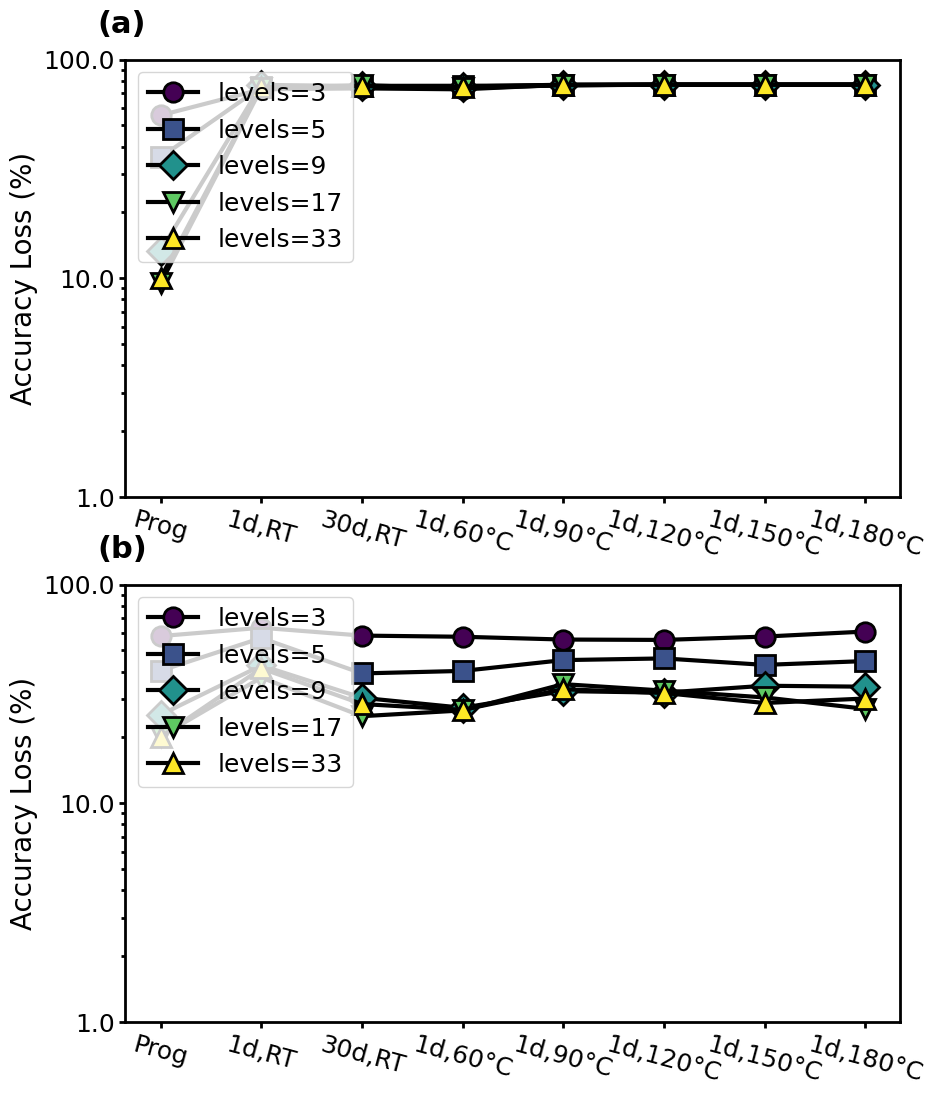

In [6]:
# Plot the results: create 4 plots, one for each noise model
# the Single Conductance Noise Model and the Compensated Single Conductance Noise Model at the top, left and right respectively
# the Experimental Noise Model and the Compensated Experimental Noise Model at the bottom, left and right respectively

# Each plot will have 5 lines, one for each level of quantization, and each line will show the mean accuracy and the standard deviation over the 10 runs
# for each noise types (the x axis) . The y axis will show the accuracy in percentage.

cmap = plt.get_cmap("viridis")
colors = cmap(np.linspace(0, 1, len(LEVELS)))
markers = ["o", "s", "D", "v", "^"]


def plot_results( accuracies, x, levels, colors, markers, title,loc, ax):
    # the function returns a ax object to be included as a subplot
    # add the non quantized model
    # ax.axhline(y=accuracy_non_quantized, color="r", linestyle="--", label="non-quantized", linewidth=3)
    for i in range(len(levels)):
        ax.plot(x,accuracy_non_quantized-  accuracies[i].mean(axis=1), label=f"levels={levels[i]}", color="k", marker=markers[i], markerfacecolor=colors[i], markeredgewidth=2, markersize=14, linewidth=3)
        # ax.fill_between(x, accuracy_non_quantized- accuracies[i].mean(axis=1) - accuracies[i].std(axis=1), accuracy_non_quantized- accuracies[i].mean(axis=1) + accuracies[i].std(axis=1), alpha=0.2, color=colors[i])
    # ax.set_title(title, fontsize=20)
    ax.set_ylabel("Accuracy Loss (%)", fontsize=20)
    # increase the size of the ticks
    ax.tick_params(axis='both', which='major', labelsize=12, width=3, length=4)
    
    # ax.set_yticks(np.arange(0, 101, 20)) 
    # set log scale for the y axis
    ax.set_yscale("log")
    # set the max of the y axis
    ax.set_ylim(1, 100)
    # show on grid with a lower alpha
    # ax.grid(which='minor', alpha=0.2)
    # ax.grid(True)
    # rotate the ticks labels of the x axis
    ax.set_xticklabels(x, rotation=-15, fontsize=18)
    # increse size of tick labels of the y axis
    ax.set_yticklabels(ax.get_yticks(), fontsize=18)
    # make the ticks thicker
    ax.tick_params(width=2)
    #increase frame thickness
    ax.spines['top'].set_linewidth(4)
    ax.spines['bottom'].set_linewidth(4)
    ax.spines['left'].set_linewidth(4)
    ax.spines['right'].set_linewidth(4)

    # increase the size of the minor ticks
    ax.tick_params(axis='both', which='minor', width=2, length=3)




    # make the borders of the plot thicker
    for axis in ['top','bottom','left','right']:
        ax.spines[axis].set_linewidth(2)
    
    ax.legend(fontsize=18, loc=loc) 




# fig, ax = plt.subplot_mosaic([["(a)", "(b)"], ["(c)", "(d)"]], figsize=(20, 12.5))
fig, ax = plt.subplot_mosaic([["(a)"],["(b)"]], figsize=(10, 12.5))
plot_results(accuracies_single, noise_types, LEVELS, colors, markers, "single", "upper left",ax["(a)"])
# plot_results(accuracy_single_compensated, noise_types, LEVELS, colors, markers, "single compensated" , "upper left", ax["(b)"])
plot_results(accuracy_experimental, noise_types, LEVELS, colors, markers, "differential" , "upper left", ax["(b)"])
# plot_results(accuracy_experimental, noise_types, LEVELS, colors, markers, "differential" , "upper left", ax["(c)"])
# plot_results(accuracy_experimental_compensated, noise_types, LEVELS, colors, markers, "differential compensated" , "upper left", ax["(d)"])
# plt.tight_layout()

# set  labels
for label, a in ax.items():
    # Use ScaledTranslation to put the label
    # - at the top left corner (axes fraction (0, 1)),
    # - offset 20 pixels left and 7 pixels up (offset points (-20, +7)),
    # i.e. just outside the axes.
    a.text(
        0.0, 1.0, label, transform=(
            a.transAxes + ScaledTranslation(-20/72, 15/72, fig.dpi_scale_trans)),
        fontsize=22, va='bottom', fontweight='bold')



# ResNet9s

In [16]:
# SEED = 1
# N_EPOCHS = 40
BATCH_SIZE = 64
# LEARNING_RATE = 0.01
N_CLASSES = 10
PATH_DATASET = cur_dir + "/../data/cifar10"

import torchvision

class TorchCutout(object):
    def __init__(self, length, fill=(0.0, 0.0, 0.0)):
        self.length = length
        self.fill = torch.tensor(fill).reshape(shape=(3, 1, 1))

    def __call__(self, img):
        h = img.size(1)
        w = img.size(2)
        y = np.random.randint(h)
        x = np.random.randint(w)
        y1 = np.clip(y - self.length // 2, 0, h)
        y2 = np.clip(y + self.length // 2, 0, h)
        x1 = np.clip(x - self.length // 2, 0, w)
        x2 = np.clip(x + self.length // 2, 0, w)
        img[:, y1:y2, x1:x2] = self.fill
        return img

def load_images():
    transform_train = transforms.Compose(
        [
            torchvision.transforms.RandomCrop(32, padding=4),
            torchvision.transforms.RandomHorizontalFlip(),
            transforms.ToTensor(), 
            transforms.Normalize(
                (0.4914, 0.4822, 0.4465),
                (0.2023, 0.1994, 0.2010)
            ),
            TorchCutout(length=8)
            ])
    
    transform_test = torchvision.transforms.Compose(
        [
            torchvision.transforms.ToTensor(),
            torchvision.transforms.Normalize(
                (0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)
            ),
        ]
    )

    train_set = datasets.CIFAR10(PATH_DATASET, train=True, download=True, transform=transform_train)
    val_set = datasets.CIFAR10(PATH_DATASET, train=False, download=True, transform=transform_test)
    train_data = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
    validation_data = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False)

    return train_data, validation_data

class LambdaLayer(torch.nn.Module):
    def __init__(self, lambd):
        super(LambdaLayer, self).__init__()
        self.lambd = lambd

    def forward(self, x):
        return self.lambd(x)


class BasicBlock(torch.nn.Module):
    expansion = 1

    def __init__(self, in_planes, planes, stride=1, option="A", RPU_CONFIG=None):
        super(BasicBlock, self).__init__()
        self.conv1 = AnalogConv2d(
            in_planes, planes, kernel_size=3, stride=stride, padding=1, bias=False, rpu_config=RPU_CONFIG,
        )
        self.bn1 = torch.nn.BatchNorm2d(planes)
        self.conv2 = AnalogConv2d(
            planes, planes, kernel_size=3, stride=1, padding=1, bias=False, rpu_config=RPU_CONFIG,
        )
        self.bn2 = torch.nn.BatchNorm2d(planes)

        self.shortcut = AnalogSequential()
        if stride != 1 or in_planes != planes:
            if option == "A":
                """
                For CIFAR10 ResNet paper uses option A.
                """
                self.shortcut = LambdaLayer(
                    lambda x: F.pad(
                        x[:, :, ::2, ::2],
                        (0, 0, 0, 0, planes // 4, planes // 4),
                        "constant",
                        0,
                    )
                )
            elif option == "B":
                self.shortcut = AnalogSequential(
                    AnalogConv2d(
                        in_planes,
                        self.expansion * planes,
                        kernel_size=1,
                        stride=stride,
                        bias=False,
                        rpu_config=RPU_CONFIG,
                    ),
                    torch.nn.BatchNorm2d(self.expansion * planes),
                )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = F.relu(out)
        return out


def Resnet9(channels, RPU_CONFIG, first_layer_quantization = True):
    """
    From https://github.com/matthias-wright/cifar10-resnet/
    """

    # resnet9 [56,112,224,224]
    # resnet9s [28,28,28,56]

    FIRST_LAYER_RPU_CONFIG = deepcopy(RPU_CONFIG)
    if first_layer_quantization == False:
        FIRST_LAYER_RPU_CONFIG.quantization = WeightQuantizerParameter(
            quantizer_type=WeightQuantizerType.NONE
        )

        print("No quantization for the first layer has been requested.")
        print("First layer RPU_CONFIG: ", FIRST_LAYER_RPU_CONFIG.quantization)
        print("Original RPU_CONFIG quantization parameter: ", RPU_CONFIG.quantization)


    model = AnalogSequential(
        # prep
        AnalogConv2d(
            in_channels=3,
            out_channels=channels[0],
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False,
            rpu_config=FIRST_LAYER_RPU_CONFIG,
        ),
        torch.nn.BatchNorm2d(num_features=channels[0], momentum=0.9),
        torch.nn.ReLU(inplace=True),
        # Layer 1
        AnalogConv2d(
            in_channels=channels[0],
            out_channels=channels[1],
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False,
            rpu_config=RPU_CONFIG,
        ),
        torch.nn.BatchNorm2d(num_features=channels[1], momentum=0.9),
        torch.nn.ReLU(inplace=True),
        torch.nn.MaxPool2d(kernel_size=2, stride=2),
        BasicBlock(in_planes=channels[1], planes=channels[1], stride=1, RPU_CONFIG=RPU_CONFIG),
        # Layer 2
        AnalogConv2d(
            in_channels=channels[1],
            out_channels=channels[2],
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False,
            rpu_config=RPU_CONFIG,
        ),
        torch.nn.BatchNorm2d(num_features=channels[2], momentum=0.9),
        torch.nn.ReLU(inplace=True),
        torch.nn.MaxPool2d(kernel_size=2, stride=2),
        # Layer 3
        AnalogConv2d(
            in_channels=channels[2],
            out_channels=channels[3],
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False,
            rpu_config=RPU_CONFIG,
        ),
        torch.nn.BatchNorm2d(num_features=channels[3], momentum=0.9),
        torch.nn.ReLU(inplace=True),
        torch.nn.MaxPool2d(kernel_size=2, stride=2),
        BasicBlock(in_planes=channels[3], planes=channels[3], stride=1, RPU_CONFIG=RPU_CONFIG),
        torch.nn.MaxPool2d(kernel_size=4, stride=4),
        torch.nn.Flatten(),
        AnalogLinear(in_features=channels[3], out_features=10, bias=True, rpu_config=RPU_CONFIG)
    )

    return model



def create_analog_network(RPU_CONFIG, first_layer_quantization = True):
    return Resnet9(channels=[28,28,28,56], RPU_CONFIG=RPU_CONFIG, first_layer_quantization = first_layer_quantization)



def test_evaluation(validation_data, model, criterion):
    """Test trained network

    Args:
        validation_data (DataLoader): Validation set to perform the evaluation
        model (nn.Module): Trained model to be evaluated
        criterion (nn.CrossEntropyLoss): criterion to compute loss

    Returns:
        nn.Module, float, float, float: model, test epoch loss, test error, and test accuracy
    """
    total_loss = 0
    predicted_ok = 0
    total_images = 0

    model.eval()

    for images, labels in validation_data:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        pred = model(images)
        loss = criterion(pred, labels)
        total_loss += loss.item() * images.size(0)

        _, predicted = torch_max(pred.data, 1)
        total_images += labels.size(0)
        predicted_ok += (predicted == labels).sum().item()
        accuracy = predicted_ok / total_images * 100
        error = (1 - predicted_ok / total_images) * 100

    epoch_loss = total_loss / len(validation_data.dataset)

    return model, epoch_loss, error, accuracy

In [25]:
from shared import resnet9s

_, validation_data = load_images()
criterion = nn.CrossEntropyLoss()

rpu_config = IdealPreset()

EPS = 0.03

# Stardard model trained on FloatingPointRPUConfig
RESULTS_NON_QUANTIZED = cur_dir + "/resnet9_base_results"
state_dict = torch.load(os.path.join(RESULTS_NON_QUANTIZED, "resnet9_base.th"), map_location=DEVICE)
non_quantized_model = resnet9s().to(DEVICE)
non_quantized_model.load_state_dict(state_dict, strict=False)
non_quantized_model = convert_to_analog(non_quantized_model, rpu_config)
non_quantized_model.eval()

_, _, _, accuracy_non_quantized = test_evaluation(validation_data, non_quantized_model, criterion)
print(f"Accuracy of the non-quantized model: {accuracy_non_quantized:.2f}%")

TIMES = 10
def evaluate_model(noise_model_class, accuracies_array):
    for i, levels in enumerate(LEVELS):
        for j, noise_type in enumerate(noise_types):
            noise_model = noise_model_class(
                file_path=cur_dir + "/../data/matlab/4bit.mat",
                type=noise_type,
                levels=levels,
                force_interpolation=True,
                compensation=False,
                g_converter=SinglePairConductanceConverter(g_max=40.)
            )

            rpu_config = deepcopy(RPU_CONFIG_PERCENTILE)
            rpu_config.quantization.levels = levels
            rpu_config.quantization.eps = EPS
            rpu_config.noise_model = noise_model

            for t in range(TIMES):
                model = resnet9s().to(DEVICE)
                model.load_state_dict(state_dict, strict=False)
                quantized_model = convert_to_analog(model, rpu_config)
                quantized_model.eval()
                quantized_model.program_analog_weights()

                _, _, _, accuracies_array[i, j, t] = test_evaluation(validation_data, quantized_model, criterion)

            print(f"Accuracy of the percentile model with eps={EPS:.3f} and levels={levels}: {accuracies_array[i, j, :].mean():.2f}%")
            del model
            del quantized_model
            torch.cuda.empty_cache()

# Accuracy evaluation of the models
accuracies_single = np.zeros((len(LEVELS), len(noise_types), TIMES))
evaluate_model(SingleConductanceNoiseModel, accuracies_single)

accuracy_single_compensated = np.zeros((len(LEVELS), len(noise_types), TIMES))
evaluate_model(CompensatedSingleConductanceNoiseModel, accuracy_single_compensated)

accuracy_experimental = np.zeros((len(LEVELS), len(noise_types), TIMES))
evaluate_model(ExperimentalNoiseModel, accuracy_experimental)   

accuracy_experimental_compensated = np.zeros((len(LEVELS), len(noise_types), TIMES))
evaluate_model(CompensatedExperimentalNoiseModel, accuracy_experimental_compensated)

# Save results
results = {
    "accuracy_non_quantized": accuracy_non_quantized,
    "accuracy_single": accuracies_single,
    "accuracy_single_compensated": accuracy_single_compensated,
    "accuracy_experimental": accuracy_experimental,
    "accuracy_experimental_compensated": accuracy_experimental_compensated,
}

if not os.path.exists(DUMP_DIR):
    os.makedirs(DUMP_DIR)
torch.save(results, os.path.join(DUMP_DIR, "results_resnet9.th"))

Files already downloaded and verified
Files already downloaded and verified


























Accuracy of the non-quantized model: 86.74%



 --------------------------------------------------------------------------------------------------
TYPE: Prog
MEDIAN VALUES: tensor([-42.2010,   0.0000,  42.2010], dtype=torch.float64)
STD VALUES: tensor([-2.3199,  0.0000,  2.3199], dtype=torch.float64)




































































































































































































































































Accuracy of the percentile model with eps=0.030 and levels=3: 31.12%



 --------------------------------------------------------------------------------------------------
TYPE: 1d,RT
MEDIAN VALUES: tensor([-26.8113,   0.0000,  26.8113], dtype=torch.float64)
STD VALUES: tensor([-3.2119,  0.0000,  3.2119], dtype=torch.float64)










In [4]:
# Load the results
results = torch.load(os.path.join(DUMP_DIR, "results_resnet9.th"))
accuracy_non_quantized = results["accuracy_non_quantized"]
accuracies_single = results["accuracy_single"]
accuracy_single_compensated = results["accuracy_single_compensated"]
accuracy_experimental = results["accuracy_experimental"]
accuracy_experimental_compensated = results["accuracy_experimental_compensated"]


/tmp/ipykernel_1700158/966790257.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x, rotation=-15, fontsize=18)
/tmp/ipykernel_1700158/966790257.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticks(), fontsize=18)
/tmp/ipykernel_1700158/966790257.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x, rotation=-15, fontsize=18)
/tmp/ipykernel_1700158/966790257.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticks(), fontsize=18)
/tmp/ipykernel_1700158/966790257.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e.

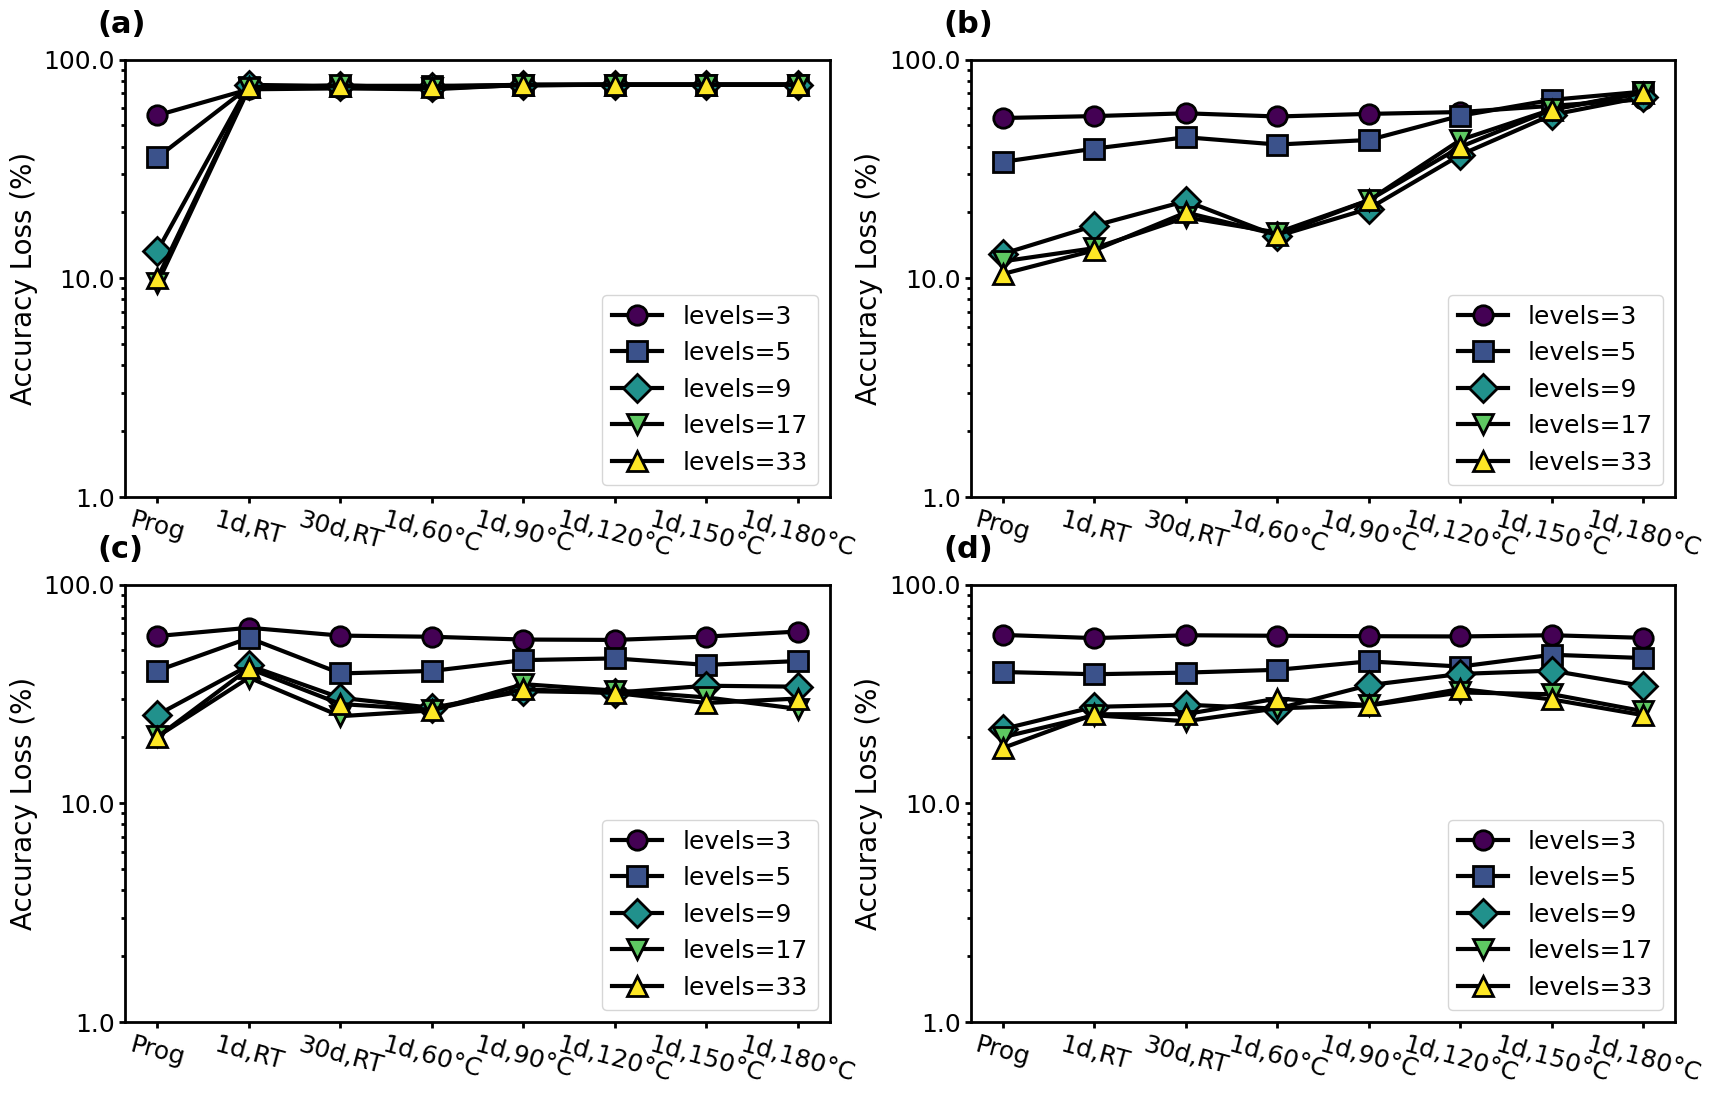

In [7]:

# Plot the results: create 4 plots, one for each noise model
# the Single Conductance Noise Model and the Compensated Single Conductance Noise Model at the top, left and right respectively
# the Experimental Noise Model and the Compensated Experimental Noise Model at the bottom, left and right respectively

# Each plot will have 5 lines, one for each level of quantization, and each line will show the mean accuracy and the standard deviation over the 10 runs


cmap = plt.get_cmap("viridis")
colors = cmap(np.linspace(0, 1, len(LEVELS)))
markers = ["o", "s", "D", "v", "^"]

# def plot_results( accuracies, x, levels, colors, markers, title, ax):
#     # the function returns a ax object to be included as a subplot
#     for i in range(len(levels)):
#         ax.plot(x, accuracies[i].mean(axis=1), label=f"levels={levels[i]}", color="k", marker=markers[i], markerfacecolor=colors[i])
#         ax.fill_between(x, accuracies[i].mean(axis=1) - accuracies[i].std(axis=1), accuracies[i].mean(axis=1) + accuracies[i].std(axis=1), alpha=0.2, color=colors[i])
#     ax.set_title(title)
#     ax.set_ylabel("accuracy (%)")
#     ax.set_ylim(0, 100)
#     # add minor ticks each 2 on the y axis
#     ax.yaxis.set_minor_locator(plt.MultipleLocator(2))
#     # show on grid with a lower alpha
#     ax.grid(which='minor', alpha=0.2)
#     ax.grid(True)
#     ax.legend()

fig, ax = plt.subplot_mosaic([["(a)", "(b)"], ["(c)", "(d)"]], figsize=(20, 12.5))
plot_results(accuracies_single, noise_types, LEVELS, colors, markers, "single", "lower right", ax["(a)"])
plot_results(accuracy_single_compensated, noise_types, LEVELS, colors, markers, "single compensated", "lower right", ax["(b)"])
plot_results(accuracy_experimental, noise_types, LEVELS, colors, markers, "differential", "lower right", ax["(c)"])
plot_results(accuracy_experimental_compensated, noise_types, LEVELS, colors, markers, "differential compensated", "lower right", ax["(d)"])

#remove the legend for (b), (c) and (d)
# ax["(b)"].legend().remove()
# ax["(c)"].legend().remove()
# ax["(d)"].legend().remove()
# plt.tight_layout()

# set  labels
for label, a in ax.items():
    # Use ScaledTranslation to put the label
    # - at the top left corner (axes fraction (0, 1)),
    # - offset 20 pixels left and 7 pixels up (offset points (-20, +7)),
    # i.e. just outside the axes.
    a.text(
        0.0, 1.0, label, transform=(
            a.transAxes + ScaledTranslation(-20/72, 15/72, fig.dpi_scale_trans)),
        fontsize=22, va='bottom', fontweight='bold')
